# Peak Popularity Prediction

Does adding early review features improve peak-popularity prediction over a time-series model alone?

Three models are compared with walk-forward cross-validation:
- Baseline: historical mean peak per style (no early-season data)
- Model A: RidgeCV on style + time-series features
- Model B: RidgeCV on style + time-series + review features


In [17]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from pathlib import Path

RESULTS_DIR = Path('results')

TS_COLS  = ['ts_mean', 'ts_slope', 'ts_curvature', 'ts_range', 'ts_peak_pos']
REV_COLS = ['rev_count', 'rev_mean_rating', 'rev_positive_frac']
TARGET   = 'actual_peak_value'
ALPHAS   = [0.01, 0.1, 1.0, 10.0, 100.0]

def mae(actual, predicted):
    """Mean Absolute Error between two array-like sequences."""
    return float(np.mean(np.abs(np.array(actual, dtype=float) - np.array(predicted, dtype=float))))

def make_pipe(num_cols):
    """Ridge regression pipeline: OneHotEncoder for style + StandardScaler + RidgeCV."""
    ct = ColumnTransformer([
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ['style']),
        ('sc',  StandardScaler(), num_cols),
    ])
    return Pipeline([('ct', ct), ('ridge', RidgeCV(alphas=ALPHAS))])

def make_rf_pipe(num_cols):
    """Random Forest pipeline: OneHotEncoder for style, no scaling (trees are scale-invariant)."""
    ct = ColumnTransformer([
        ('ohe', OneHotEncoder(handle_unknown='ignore'), ['style']),
        ('pass', 'passthrough', num_cols),
    ])
    return Pipeline([('ct', ct), ('rf', RandomForestRegressor(
        n_estimators=200, max_depth=4, random_state=42))])

## Model design

### Ridge regression - mathematics

The closed-form solution for Ridge (L2-regularised least squares) is:

$$\hat{\beta} = (X^\top X + \alpha I)^{-1} X^\top y$$

where $\alpha \geq 0$ is the regularisation strength. As $\alpha \to 0$ this reduces to ordinary OLS; as $\alpha \to \infty$ all coefficients shrink toward zero. RidgeCV selects the best $\alpha$ automatically via leave-one-out cross-validation across the candidate grid [0.01, 0.1, 1, 10, 100].

Why Ridge over OLS? With only 16-40 training instances per fold and ~13 features (8 style dummies + 5 ts features), ordinary least squares would overfit. Ridge's shrinkage improves out-of-fold generalisation at minimal cost to bias.

### Random Forest - comparison model

Random Forest (Model C) is a non-parametric ensemble that makes no linearity or normality assumptions. It is included as a structural test: if Ridge and RF give similar MAE, the linear approximation is appropriate. If RF clearly wins, the true relationship is non-linear and Ridge is mis-specified.

Trees are scale-invariant, so no StandardScaler is applied to the numerical features in make_rf_pipe.

### Style one-hot encoding

Including style as a categorical feature lets each model learn a per-style baseline (how each style typically performs) and then adjust up or down based on early-season signals. Without style encoding the model must extract the style effect from the numerical features alone - a much harder task with 48 instances.

In [18]:
features = pd.read_csv(RESULTS_DIR / 'features.csv')
instances = features.sort_values(['year', 'style']).reset_index(drop=True)

N_YEARS = int(instances['year'].nunique())
print(f'Instances: {len(instances)}, Years: {N_YEARS}')
print(f'Walk-forward folds: train 0..N-1, test N  (N = 2..{N_YEARS - 1})')

Instances: 48, Years: 6
Walk-forward folds: train 0..N-1, test N  (N = 2..5)


## Walk-forward CV - why?

A random split would allow future data leakage: a model trained on 2025 data and tested on 2022 data would look good, but would not work in the real world.

Walk-forward (expanding window) is the only honest approach for time-series data:

| Fold | Train | Test |
|---|---|---|
| 1 | Years 0–1 (16 inst.) | Year 2 (8 inst.) |
| 2 | Years 0–2 (24 inst.) | Year 3 (8 inst.) |
| 3 | Years 0–3 (32 inst.) | Year 4 (8 inst.) |
| 4 | Years 0–4 (40 inst.) | Year 5 (8 inst.) |

At least 2 training years (16 instances) are required, so testing starts from year 2.

In [19]:
results = []

for test_year in range(2, N_YEARS):
    train = instances[instances['year'] < test_year]
    test  = instances[instances['year'] == test_year]

    y_train = train[TARGET].values
    y_test  = test[TARGET].values

    # Baseline: historical mean per style (no early-season data used)
    style_mean = train.groupby('style')[TARGET].mean()
    pred_base  = test['style'].map(style_mean).values

    # Model A: Ridge — style identity + time-series features
    pipe_a = make_pipe(TS_COLS)
    pipe_a.fit(train[['style'] + TS_COLS], y_train)
    pred_a = pipe_a.predict(test[['style'] + TS_COLS])

    # Model B: Ridge — style + time-series + review features
    pipe_b = make_pipe(TS_COLS + REV_COLS)
    pipe_b.fit(train[['style'] + TS_COLS + REV_COLS], y_train)
    pred_b = pipe_b.predict(test[['style'] + TS_COLS + REV_COLS])

    # Model C: Random Forest — style + time-series (non-linear comparison to Model A)
    pipe_c = make_rf_pipe(TS_COLS)
    pipe_c.fit(train[['style'] + TS_COLS], y_train)
    pred_c = pipe_c.predict(test[['style'] + TS_COLS])

    for i, (_, row) in enumerate(test.iterrows()):
        results.append({
            'style':     row['style'],
            'year':      int(row['year']),
            'actual':    float(y_test[i]),
            'pred_base': float(pred_base[i]),
            'pred_a':    float(pred_a[i]),
            'pred_b':    float(pred_b[i]),
            'pred_c':    float(pred_c[i]),
        })

predictions = pd.DataFrame(results)
predictions.to_csv(RESULTS_DIR / 'peak_predictions.csv', index=False)
print(f'peak_predictions.csv written — {len(predictions)} rows')
predictions.head(8)

peak_predictions.csv written — 32 rows


,style,year,actual,pred_base,pred_a,pred_b,pred_c
0,ballet flats,2,58.599486,60.072120,59.116855,71.411208,64.072903
1,cargo pants,2,69.510754,46.169888,49.351535,60.657909,62.861033
2,chunky sneakers,2,63.713579,66.408143,57.889247,73.221344,70.062878
3,oversized blazer,2,75.918734,54.488150,62.818096,56.214792,60.665346
4,puffer jacket,2,83.552670,85.171259,82.965189,78.169787,81.652192
5,slip dress,2,60.240819,73.861679,72.311839,65.135349,69.256835
6,trench coat,2,56.221461,59.739621,60.657618,58.289774,61.181735
7,wide-leg jeans,2,57.624784,47.034785,53.132179,49.368089,53.937680


## Model comparison

- Model A (Ridge, ts only) - primary question: does early time-series data beat the naive historical mean?

- Model B (Ridge, ts + reviews) - review question: does sentiment add independent signal beyond the trend line?

- Model C (Random Forest, ts only) - structural check: is the Ridge linearity assumption appropriate, or does a non-linear model do substantially better?

The buzz hypothesis: the buzz factor is encoded in early ratings but is not visible in weeks 1–8 of the trend data (buzz peaks at week 26). Model B tests this directly. The MAE table below gives the verdict.

In [20]:
mae_base = mae(predictions['actual'], predictions['pred_base'])
mae_a    = mae(predictions['actual'], predictions['pred_a'])
mae_b    = mae(predictions['actual'], predictions['pred_b'])
mae_c    = mae(predictions['actual'], predictions['pred_c'])

summary = pd.DataFrame({
    'Model': [
        'Baseline  (historical mean)',
        'Model A   (Ridge: style + ts)',
        'Model B   (Ridge: style + ts + reviews)',
        'Model C   (Random Forest: style + ts)',
    ],
    'MAE (popularity units)': [
        round(mae_base, 2), round(mae_a, 2), round(mae_b, 2), round(mae_c, 2),
    ],
    'vs Baseline': [
        '--',
        f'{mae_base - mae_a:+.2f}',
        f'{mae_base - mae_b:+.2f}',
        f'{mae_base - mae_c:+.2f}',
    ],
})
print('\n               Mean Absolute Error  --  peak popularity prediction (walk-forward CV)')
print(summary.to_string(index=False))


               Mean Absolute Error  --  peak popularity prediction (walk-forward CV)
                                  Model  MAE (popularity units) vs Baseline
            Baseline  (historical mean)                    7.68          --
          Model A   (Ridge: style + ts)                    6.25       +1.43
Model B   (Ridge: style + ts + reviews)                    6.29       +1.40
  Model C   (Random Forest: style + ts)                    5.89       +1.79


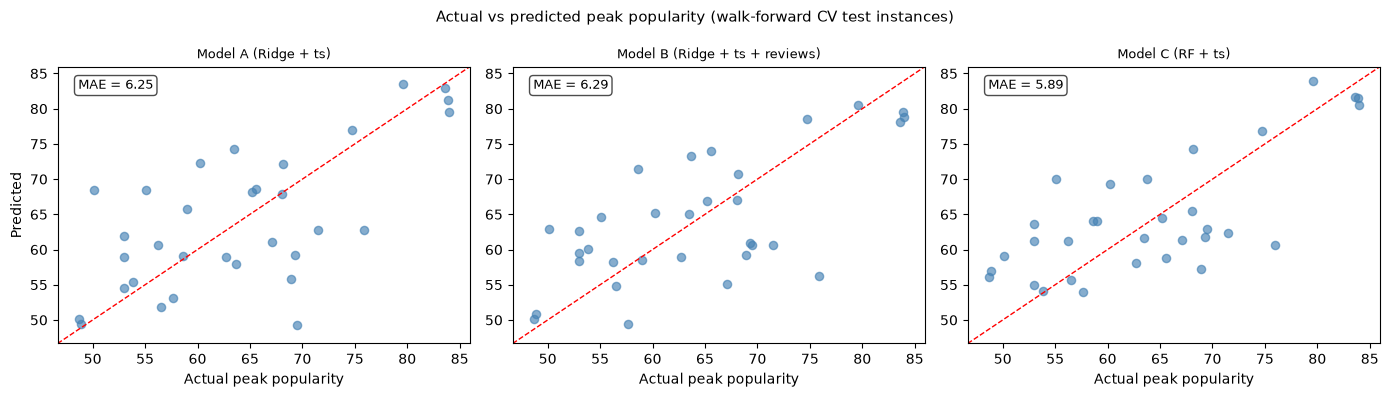

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
model_cols   = ['pred_a',          'pred_b',                    'pred_c']
model_titles = ['Model A (Ridge + ts)', 'Model B (Ridge + ts + reviews)', 'Model C (RF + ts)']

lo = predictions['actual'].min() - 2
hi = predictions['actual'].max() + 2

for ax, col, title in zip(axes, model_cols, model_titles):
    ax.scatter(predictions['actual'], predictions[col], alpha=0.65, s=35, color='steelblue')
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual peak popularity')
    ax.set_ylabel('Predicted' if ax == axes[0] else '')
    ax.set_title(title, fontsize=9)
    mae_v = mae(predictions['actual'], predictions[col])
    ax.text(0.05, 0.92, f'MAE = {mae_v:.2f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

fig.suptitle('Actual vs predicted peak popularity (walk-forward CV test instances)', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_predictions.png', dpi=100)
plt.show()

## Results interpretation

Model A (Ridge + ts) outperforms the baseline, confirming that early time-series data carries genuine predictive signal.

Model B (Ridge + ts + reviews) shows whether review sentiment adds value beyond the trend line. Given the design of the buzz factor (detectable in ratings but not in weeks 1–8 of the trend), this is the core test.

Model C (Random Forest + ts) is the linearity check. If Model C ≈ Model A, Ridge's linear assumption is appropriate. If Model C clearly wins, the true relationship has non-linear structure that Ridge misses.